In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# !pip uninstall -y transformers setfit
# !pip install "transformers<4.41" "setfit>=0.7,<0.8"

In [3]:
# !pip uninstall -y setfit sentence-transformers transformers datasets
# !pip install \
#   setfit==0.7.0 \
#   sentence-transformers==2.6.1 \
#   transformers==4.40.2 \
#   datasets==2.18.0

In [ ]:
from setfit import SetFitModel, SetFitTrainer
import os
os.environ["WANDB_DISABLED"] = "true"

In [4]:
import os

running='colab'

if running=='local':
    os.chdir(os.path.dirname(os.getcwd()))
    project_path = os.getcwd()
elif running=='colab':
    from google.colab import drive
    drive.mount('/content/drive')
    project_path_colab = "/content/drive/MyDrive/Projeto ML/2025/AD/third_setup"

    repo_name = "adaptative-text-anomaly-detection"
    project_path = os.path.join(project_path_colab, repo_name)
    os.chdir(project_path)
else:
    raise ValueError("Invalid running environment. Choose 'local' or 'colab'.")

Mounted at /content/drive


In [ ]:
import sys
sys.path.append(r'../src')
sys.path.append(r'./src')

import numpy as np
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import seaborn as sns

from sentence_transformers.losses import CosineSimilarityLoss
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
import numpy as np

from pipeline.anomaly_detection import label_normal_vs_anomaly,adjust_contamination, pretty_print_data_info, split_data
from pipeline.benchmark_runner import benchmark_unsupervised_models, benchmark_semisupervised_models

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-971/4058844882.py", line 6, in <cell line: 0>
    from tqdm import tqdm
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1322, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap_external>", line 1532, in find_spec
  File "<frozen importlib._bootstrap_external>", line 1504, in _get_spec
  File "<frozen importlib._bootstrap_external>", line 1483, in _path_importer_cache
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showt

In [ ]:
project_path_src= '/content/drive/MyDrive/Projeto ML/2026/Master/Code'
os.chdir(project_path)

In [ ]:
config = {
    "en": {
        "datasets": [
            "tweets-hate-speech-detection/tweets_hate_speech_detection",
            "SetFit/20_newsgroups",
            "cardiffnlp/tweet_eval"
        ],
        "encoders": [
            "sentence-transformers/distiluse-base-multilingual-cased-v1",
            "sentence-transformers/distiluse-base-multilingual-cased-v2",
            # "FacebookAI/xlm-roberta-large"
        ]
    },
    "pt": {
        "datasets": [
            "JAugusto97/told-br",
            "wikinews",
            "augustop/portuguese-tweets-for-sentiment-analysis"
        ],
        "encoders": [
            "sentence-transformers/distiluse-base-multilingual-cased-v1",
            "sentence-transformers/distiluse-base-multilingual-cased-v2",
        #     "FacebookAI/xlm-roberta-large",
        #     "neuralmind/bert-base-portuguese-cased",
        #     "neuralmind/bert-large-portuguese-cased",
        #     "PORTULAN/serafim-100m-portuguese-pt-sentence-encoder-ir"
        ]
    }
}


In [ ]:
dataset_short="20_newsgroups"
encoder = "sentence-transformers/distiluse-base-multilingual-cased-v2"
# encoder = "sentence-transformers/paraphrase-mpnet-base-v2"
K_PER_CLASS = 20

In [ ]:
def demonstrate_labels(dataset):

  normal_examples = dataset[dataset["label"] == 0].sample(5, random_state=42)   # inliers
  anomaly_examples = dataset[dataset["label"] == 1].sample(5, random_state=42) # outliers

  print("\n=== Positive (Anomalies) ===")
  for t in anomaly_examples["text"]:
      print("-", t)

  print("\n=== Negative (Normal) ===")
  for t in normal_examples["text"]:
      print("-", t)

In [ ]:

encoder_short= encoder.split("/")[-1]

texts_df = pd.read_parquet(os.path.join(project_path, f"data/texts_{dataset_short}.parquet"))
labels_df = pd.read_parquet(os.path.join(project_path, f"data/labels_{dataset_short}.parquet"))
embeddings_df = pd.read_parquet(os.path.join(project_path, f"data/embeddings_{dataset_short}_{encoder_short}.parquet"))

df = pd.DataFrame({
    "text": texts_df.squeeze().tolist(),
    "label": labels_df.squeeze().values
})


print('Label distribution:')
print(df['label'].value_counts())

Label distribution:
label
10    999
15    997
8     996
9     994
11    991
13    990
7     990
5     988
14    987
2     985
12    984
3     982
6     975
1     973
4     963
17    940
16    910
0     799
18    775
19    628
Name: count, dtype: int64


In [ ]:
model = SetFitModel.from_pretrained(encoder)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/610 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


In [ ]:
labeled_anomalies_df = label_normal_vs_anomaly(labels_df, as_df=True)

texts, labels, embeddings = adjust_contamination(
    texts=texts_df.squeeze().tolist(),
    labels=labeled_anomalies_df.squeeze().values,
    embeddings=embeddings_df.values,
    perc_anomalous=0.05
)

pretty_print_data_info(texts, labels, embeddings)
demonstrate_labels(pd.DataFrame({"text": texts, "label": labels}))

✅ Selected normal label (inlier → 0): 10
⚠️  Anomaly labels (outlier → 1): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Shape of embeddings: (1048, 512)
Shape of labels: (1048,)
Number of anomalies: 49
Number of normal: 999
Percentage of anomalies: 0.046755725190839696
Shape of texts: 1048

=== Positive (Anomalies) ===
- Has anybody heard about a thing called a MacWatch? I saw it on TV a
couple of years ago, it is a watch with a reviever and a transmitter for
your mac. The practical upshot is that your Mac can page your watch and
display a small message. My flatmate is off to the states for a week or
two soon and I am interested in getting one. Any info would be
appreciated.
- Excerpts from netnews.comp.windows.x: 23-Apr-93 X Toolkits Paul
Prescod@undergrad.m (1132)



If you'r

In [ ]:
def prepare_data_splits_for_anomaly_detection(
    texts: list,
    embeddings: np.ndarray,
    labels: np.ndarray,
    initial_test_size: float = 0.2,
    k_per_class: int = 20,
    setfit_eval_size: float = 0.3,
    random_state: int = 42,
    verbose: bool = True
) -> tuple:
    """
    Prepares data splits for anomaly detection tasks, including initial train/test,
    few-shot samples for SetFit training, and remaining downstream data.

    Args:
        texts (list): A list of text samples.
        embeddings (np.ndarray): A NumPy array of embeddings corresponding to the texts.
        labels (np.ndarray): A NumPy array of labels (0 for normal, 1 for anomaly)
                              corresponding to the texts.
        initial_test_size (float, optional): The proportion of the dataset to include
                                             in the final test split. Defaults to 0.2.
        k_per_class (int, optional): The number of samples to select per class for
                                     few-shot training. Defaults to 20.
        setfit_eval_size (float, optional): The proportion of few-shot samples to use
                                            for SetFit evaluation. Defaults to 0.3.
        random_state (int, optional): Seed for random number generators for reproducibility.
                                      Defaults to 42.
        verbose (bool, optional): If True, print progress and information during splitting. Defaults to True.

    Returns:
        tuple: A tuple containing four dictionaries:
               - downstream_train (dict): Contains texts, embeddings, and labels for the downstream training pool.
               - test_set (dict): Contains texts, embeddings, and labels for the final test set.
               - setfit_data (dict): Contains 'train_dataset' (Hugging Face Dataset for SetFit few-shot training) and 'eval_dataset' (Hugging Face Dataset for SetFit few-shot evaluation).
               - remaining_downstream (dict): Contains texts, embeddings, and labels remaining after few-shot extraction.
    """
    texts_downstream_train, texts_test_set, \
    embeddings_downstream_train, embeddings_test_set, \
    labels_downstream_train, labels_test_set = train_test_split(
        np.array(texts, dtype=object),
        embeddings,
        np.array(labels, dtype=int),
        test_size=initial_test_size,
        stratify=np.array(labels, dtype=int),
        random_state=random_state
    )

    if verbose:
        print("Initial split into Downstream Training Pool and Test Set:")
        print(f"Downstream Train Set: {embeddings_downstream_train.shape} (Labels: {labels_downstream_train.shape})")
        print(f"Test Set: {embeddings_test_set.shape} (Labels: {labels_test_set.shape})")

    rng = np.random.default_rng(random_state)

    idx_by_class = defaultdict(list)
    for i, y in enumerate(labels_downstream_train):
        idx_by_class[int(y)].append(i)

    few_idx = []
    for y, idxs in idx_by_class.items():
        take = min(k_per_class, len(idxs))
        few_idx.extend(rng.choice(idxs, size=take, replace=False))

    few_texts = texts_downstream_train[few_idx].tolist()
    few_labels = labels_downstream_train[few_idx].tolist()

    if verbose:
        print(f"\nExtracted few-shot samples: {len(few_texts)} samples (with {few_labels.count(1)} outliers).")

    train_texts_sf, eval_texts_sf, train_labels_sf, eval_labels_sf = train_test_split(
        few_texts, few_labels, test_size=setfit_eval_size, stratify=few_labels, random_state=random_state
    )

    if verbose:
        print("\nSetFit Few-shot Training and Evaluation Splits:")
        print(f"SetFit Train: {len(train_texts_sf)} samples (Outliers: {train_labels_sf.count(1)})")
        print(f"SetFit Eval: {len(eval_texts_sf)} samples (Outliers: {eval_labels_sf.count(1)})")

    train_dataset_sf = Dataset.from_dict({"text": train_texts_sf, "label": train_labels_sf})
    eval_dataset_sf = Dataset.from_dict({"text": eval_texts_sf, "label": eval_labels_sf})

    if verbose:
        print("\nCreated SetFit Dataset objects: train_dataset_sf and eval_dataset_sf.")

    all_downstream_train_indices = np.arange(len(texts_downstream_train))
    remaining_downstream_indices = np.setdiff1d(all_downstream_train_indices, few_idx)

    texts_remaining_downstream = texts_downstream_train[remaining_downstream_indices].tolist()
    embeddings_remaining_downstream = embeddings_downstream_train[remaining_downstream_indices]
    labels_remaining_downstream = labels_downstream_train[remaining_downstream_indices].tolist()

    if verbose:
        print(f"\nRemaining Downstream Pool (for other model training/eval): {len(texts_remaining_downstream)} samples.")

    downstream_train = {
        'texts': texts_downstream_train.tolist(),
        'embeddings': embeddings_downstream_train,
        'labels': labels_downstream_train.tolist()
    }
    test_set = {
        'texts': texts_test_set.tolist(),
        'embeddings': embeddings_test_set,
        'labels': labels_test_set.tolist()
    }
    setfit_data = {
        'train_dataset': train_dataset_sf,
        'eval_dataset': eval_dataset_sf
    }
    remaining_downstream = {
        'texts': texts_remaining_downstream,
        'embeddings': embeddings_remaining_downstream,
        'labels': labels_remaining_downstream
    }


    return downstream_train, test_set, setfit_data, remaining_downstream


def compute_metrics(preds, labels):
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="binary"),
        "precision": precision_score(labels, preds, average="binary"),
        "recall": recall_score(labels, preds, average="binary")
    }

In [ ]:
downstream_train, test_set, setfit_data, remaining_downstream = prepare_data_splits_for_anomaly_detection(texts,
                                                                                                            embeddings,
                                                                                                            labels,
                                                                                                            k_per_class=K_PER_CLASS)

Initial split into Downstream Training Pool and Test Set:
Downstream Train Set: (838, 512) (Labels: (838,))
Test Set: (210, 512) (Labels: (210,))

Extracted few-shot samples: 40 samples (with 20 outliers).

SetFit Few-shot Training and Evaluation Splits:
SetFit Train: 28 samples (Outliers: 14)
SetFit Eval: 12 samples (Outliers: 6)

Created SetFit Dataset objects: train_dataset_sf and eval_dataset_sf.

Remaining Downstream Pool (for other model training/eval): 798 samples.


In [ ]:
def train_and_evaluate_setfit_model(
    model,
    setfit_data,
    test_set,
    loss_class= CosineSimilarityLoss,
    compute_metrics=compute_metrics,
    num_iterations=10,
    num_epochs=1,
    column_mapping={"text": "text", "label": "label"},
    batch_size=4,
    seed=42,
    verbose=True
) -> tuple:
    """
    Trains a SetFit model and evaluates its performance on both
    the training and test sets.
    """

    if verbose:
        print("\nStarting SetFit training...")

    trainer = SetFitTrainer(
        model=model,
        train_dataset=setfit_data["train_dataset"],
        eval_dataset=setfit_data["eval_dataset"],
        loss_class=loss_class,
        num_iterations=num_iterations,
        num_epochs=num_epochs,
        column_mapping=column_mapping,
        metric=compute_metrics,
        batch_size=batch_size,
        seed=seed,
    )

    trainer.train()

    # =========================
    # Train metrics (FINAL MODEL)
    # =========================
    if verbose:
        print("\nEvaluating on Train Set...")

    train_texts = setfit_data["train_dataset"][column_mapping["text"]]
    train_labels = setfit_data["train_dataset"][column_mapping["label"]]

    y_pred_train = trainer.model.predict(train_texts)
    y_proba_train = trainer.model.predict_proba(train_texts)[:, 1]

    train_metrics = compute_metrics(y_pred_train, train_labels)
    train_metrics.update({
        "roc_auc": roc_auc_score(train_labels, y_proba_train),
        "pr_auc": average_precision_score(train_labels, y_proba_train),
    })

    # =========================
    # Test metrics
    # =========================
    if verbose:
        print("\nEvaluating on Test Set...")

    y_pred_test = trainer.model.predict(test_set["texts"])
    y_proba_test = trainer.model.predict_proba(test_set["texts"])[:, 1]

    test_metrics = compute_metrics(y_pred_test, test_set["labels"])
    test_metrics.update({
        "roc_auc": roc_auc_score(test_set["labels"], y_proba_test),
        "pr_auc": average_precision_score(test_set["labels"], y_proba_test),
    })

    if verbose:
        print("\n=== Train Set Performance ===")
        print(train_metrics)
        print("\n=== Test Set Performance ===")
        print(test_metrics)

    return {
        "train": train_metrics,
        "test": test_metrics
    }, trainer


In [ ]:
metrics, trainer = train_and_evaluate_setfit_model(model, setfit_data, test_set, verbose=True)

Applying column mapping to training dataset



Starting SetFit training...


Generating Training Pairs:   0%|          | 0/10 [00:00<?, ?it/s]

***** Running training *****
  Num examples = 560
  Num epochs = 1
  Total optimization steps = 140
  Total train batch size = 4


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/140 [00:00<?, ?it/s]


Evaluating on Train Set...

Evaluating on Test Set...

=== Train Set Performance ===
{'accuracy': 1.0, 'f1': 1.0, 'precision': 1.0, 'recall': 1.0, 'roc_auc': np.float64(1.0), 'pr_auc': np.float64(0.9999999999999999)}

=== Test Set Performance ===
{'accuracy': 0.9285714285714286, 'f1': 0.5161290322580645, 'precision': 0.38095238095238093, 'recall': 0.8, 'roc_auc': np.float64(0.9844999999999999), 'pr_auc': np.float64(0.8593706293706294)}


In [ ]:
# downstream_train.update({'embeddings_sf': trainer.model.encode(downstream_train['texts'])})

downstream_train.update({
    'embeddings_sf': trainer.model.model_body.encode(downstream_train['texts'])
})

In [ ]:
# test_set.update({'embeddings_sf': trainer.model.encode(test_set['texts'])})

test_set.update({
    'embeddings_sf': trainer.model.model_body.encode(test_set['texts'])
})

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from datetime import datetime

def plot_tsne_comparison(
    embeddings_a,
    embeddings_b,
    labels,
    title_a,
    title_b,
    dataset_short,
    encoder_short,
    save_dir,
    stage="comparison",
    max_points=5000,
    pca_dims=50,
    random_state=42,
    save=True
):
    labels = np.asarray(labels)
    n = embeddings_a.shape[0]
    if n < 2:
        return

    # --- subsample ONCE (shared) ---
    if n > max_points:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=max_points, replace=False)
    else:
        idx = np.arange(n)

    X1 = embeddings_a[idx].copy()
    X2 = embeddings_b[idx].copy()
    y = labels[idx].copy()

    n_used = len(idx)
    print(f"Running t-SNE comparison on {n_used} samples")

    # --- PCA ---
    if X1.shape[1] > pca_dims:
        pca = PCA(n_components=pca_dims, random_state=random_state)
        X1 = pca.fit_transform(X1)
        X2 = pca.transform(X2)

    # --- t-SNE ---
    def run_tsne(X):
        tsne = TSNE(
            n_components=2,
            perplexity=min(30, len(X) - 1),
            method="barnes_hut",
            init="pca",
            learning_rate="auto",
            max_iter=1000,
            random_state=random_state
        )
        return tsne.fit_transform(X)

    X1_2d = run_tsne(X1)
    X2_2d = run_tsne(X2)

    df1 = pd.DataFrame({"x": X1_2d[:, 0], "y": X1_2d[:, 1], "label": y})
    df2 = pd.DataFrame({"x": X2_2d[:, 0], "y": X2_2d[:, 1], "label": y})

    # --- plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False, sharey=False)

    sns.scatterplot(data=df1, x="x", y="y", hue="label", alpha=0.7, ax=axes[0], legend=True)
    axes[0].set_title(title_a)

    sns.scatterplot(data=df2, x="x", y="y", hue="label", alpha=0.7, ax=axes[1], legend=False)
    axes[1].set_title(title_b)

    fig.suptitle(f"t-SNE Embedding Comparison — {dataset_short}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # --- save ---
    if save:
        os.makedirs(save_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        filename = (
            f"tsne_compare_{dataset_short}_"
            f"{encoder_short}_"
            f"{stage}_"
            f"n{n_used}_"
            f"{timestamp}.png"
        )

        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath, dpi=200, bbox_inches="tight")
        print(f"Saved plot to: {filepath}")

    plt.show()


Running t-SNE comparison on 838 samples
Saved plot to: /content/drive/MyDrive/Projeto ML/2026/Master/Code/plots/tsne_embeddings_visualization/N_20/tsne_compare_20_newsgroups_distiluse-base-multilingual-cased-v2_pre_vs_post_setfit_n838_20260222_211459.png


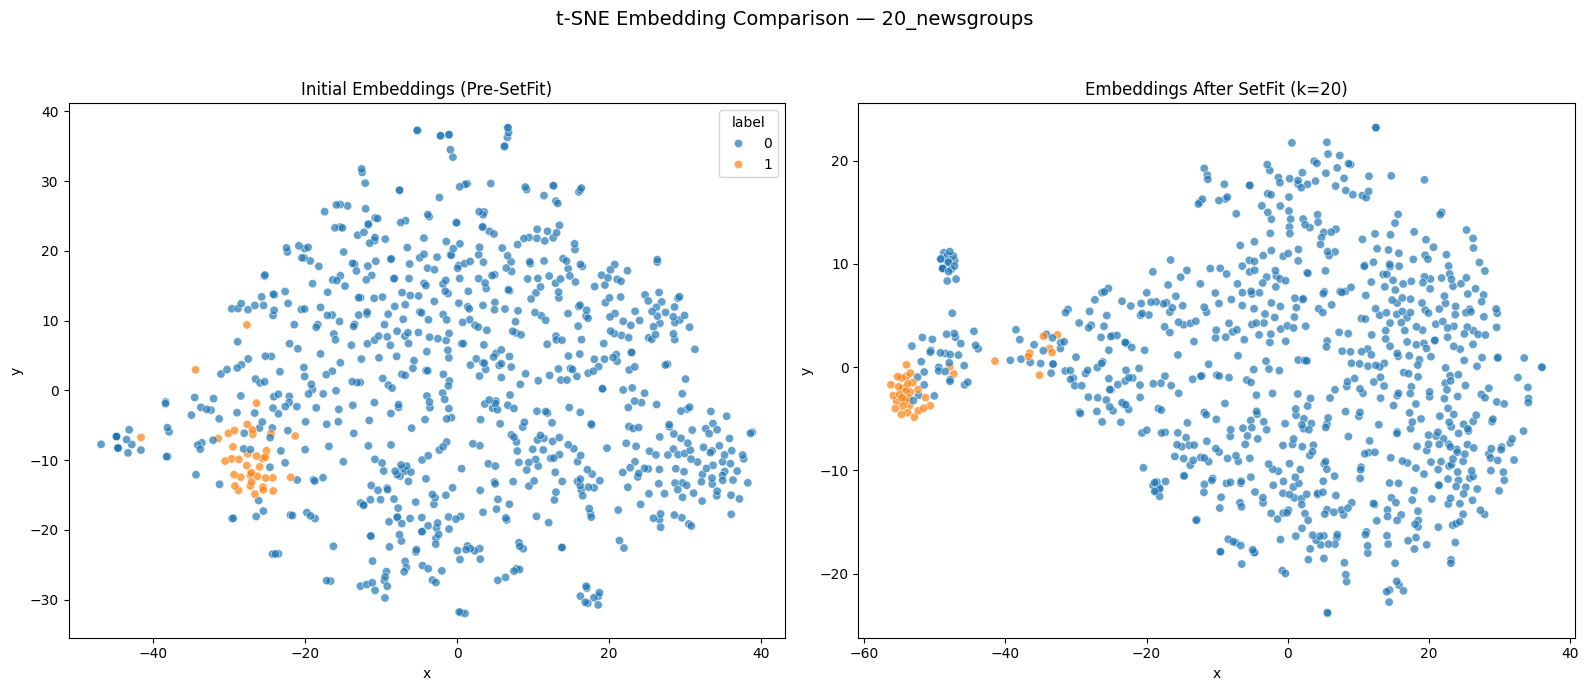

In [ ]:
save_plot = f"/content/drive/MyDrive/Projeto ML/2026/Master/Code/plots/tsne_embeddings_visualization/N_{K_PER_CLASS}"

if not os.path.exists(save_plot):
    os.makedirs(save_plot)

plot_tsne_comparison(
    embeddings_a=downstream_train["embeddings"],
    embeddings_b=downstream_train["embeddings_sf"],
    labels=downstream_train["labels"],
    title_a="Initial Embeddings (Pre-SetFit)",
    title_b=f"Embeddings After SetFit (k={K_PER_CLASS})",
    dataset_short=dataset_short,
    encoder_short=encoder_short,
    save_dir=save_plot,
    stage="pre_vs_post_setfit"
)


In [ ]:
# Testing semi supervised

In [ ]:
!pip install deepod

INFO: pip is looking at multiple versions of deepod to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, average_precision_score
import inspect
import time

def run_semi_supervised_benchmark(
    model_cls,
    model_kwargs,
    X_train,
    y_train,
    X_test,
    y_test,
    n_known_list,
    method_name,
    seed=42,
    device=None,
    verbose=True,
):

    y_train = np.asarray(y_train)
    y_test = np.asarray(y_test)

    all_anomaly_idxs = np.where(y_train == 1)[0]
    total_available = len(all_anomaly_idxs)

    if verbose:
        print(f"\n[{method_name}] Available anomalies: {total_available}")
        print(f"[{method_name}] Using n_known_list = {n_known_list}")

    rng = np.random.default_rng(seed)
    results = []

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    init_params = inspect.signature(model_cls.__init__).parameters

    for n in n_known_list:
        if n > total_available:
            continue

        sampled_idxs = rng.choice(all_anomaly_idxs, size=n, replace=False)

        y_train_semi = np.zeros(len(y_train), dtype=int)
        y_train_semi[sampled_idxs] = 1

        kwargs = dict(model_kwargs)

        if "device" in init_params:
            kwargs["device"] = device

        if "random_state" in init_params:
            kwargs["random_state"] = seed

        if "input_dim" in init_params:
            kwargs["input_dim"] = X_train.shape[1]

        clf = model_cls(**kwargs)

        t0 = time.perf_counter()
        clf.fit(X_train, y_train_semi)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        scores = clf.decision_function(X_test)
        inference_time = time.perf_counter() - t1

        results.append({
            "method": method_name,
            "model": model_cls.__name__,
            "n_known_anomalies": n,
            "roc_auc": roc_auc_score(y_test, scores),
            "pr_auc": average_precision_score(y_test, scores),
            "train_time_sec": train_time,
            "inference_time_sec": inference_time,
            "total_time_sec": train_time + inference_time,
        })

        if verbose:
            print(
                f"[{method_name}] n={n} done | "
                f"train={train_time:.3f}s | infer={inference_time:.3f}s"
            )

    return pd.DataFrame(results)


def plot_semi_supervised_benchmark(
    results_df,
    metric="roc_auc",
    baseline_value=None,
    baseline_label=None,
    title=None,
    figsize=(10, 6),
    save_path=None,
):
    """
    Plot semi-supervised benchmark curves.
    """

    plt.figure(figsize=figsize)

    sns.lineplot(
        data=results_df,
        x="n_known_anomalies",
        y=metric,
        hue="method",
        marker="o",
        linewidth=2.5,
    )

    if baseline_value is not None:
        label = baseline_label or f"Baseline ({metric.upper()}={baseline_value:.3f})"
        plt.axhline(
            y=baseline_value,
            linestyle="--",
            linewidth=2,
            label=label,
        )

    xs = sorted(results_df["n_known_anomalies"].unique())
    plt.xscale("log")
    plt.xticks(xs, xs)

    plt.xlabel("Number of Known Anomalies (log scale)")
    plt.ylabel(metric.replace("_", " ").upper())
    plt.title(title or "Semi-Supervised Anomaly Detection Benchmark")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(
    title="Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Saved plot to: {save_path}")

    plt.show()

def build_n_known_list(total_available, base=[5,10, 20, 50, 100, 200, 500]):
    """
    Build n_known list under a fixed absolute-budget protocol.

    - Uses only the canonical values in `base`.
    - Drops values that exceed dataset capacity.
    - Does NOT invent new values (to preserve comparability).
    """

    valid = [n for n in base if n <= total_available]

    if len(valid) == 0:
        print(f"[WARNING] Dataset supports fewer than {min(base)} anomalies "
              f"(total_available={total_available}). No valid n_known values.")

    return valid


In [ ]:
import tensorflow as tf
import numpy as np

class MLP:
    """
    TensorFlow MLP with DeepOD-compatible interface.
    """

    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64),
        lr=1e-3,
        epochs=20,
        batch_size=256,
        verbose=0,
        random_state=42,
    ):
        tf.keras.utils.set_random_seed(random_state)

        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose

        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Input(shape=(input_dim,)))

        for h in hidden_dims:
            self.model.add(tf.keras.layers.Dense(h, activation="relu"))

        self.model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
        )

    def fit(self, X, y):
        self.model.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
        )

    def decision_function(self, X):
        # anomaly score = P(y=1)
        return self.model.predict(X, batch_size=1024).ravel()


In [ ]:
from deepod.models import DevNet, DeepSAD

MODEL_REGISTRY = {
    "DevNet": {
        "cls": DevNet,
        "kwargs": {"epochs": 20, "verbose": 0},
    },
    "DeepSAD": {
        "cls": DeepSAD,
        "kwargs": {"epochs": 20, "verbose": 0},
    },
    "MLP": {
        "cls": MLP,
        "kwargs": {
            "epochs": 20,
            "hidden_dims": (256, 128),
            "batch_size": 256,
            "verbose": 0,
        },
    },
}


EMBEDDING_CONFIGS = {
    "Original": {
        "X_train": downstream_train["embeddings"],
        "X_test": test_set["embeddings"],
    },
    "SetFit": {
        "X_train": downstream_train["embeddings_sf"],
        "X_test": test_set["embeddings_sf"],
    },
}

In [ ]:
all_results = []

total_available = (pd.Series(downstream_train['labels'])==1).sum()
n_known_list = build_n_known_list(total_available)

print("Final n_known_list:", n_known_list)

for model_name, model_cfg in MODEL_REGISTRY.items():
    for emb_name, emb_cfg in EMBEDDING_CONFIGS.items():

        if emb_name == "SetFit":
          method_name = f"{model_name} (SetFit, k={K_PER_CLASS})"
        else:
            method_name = f"{model_name} (Original)"

        print(f"\nRunning: {method_name}")

        df = run_semi_supervised_benchmark(
            model_cls=model_cfg["cls"],
            model_kwargs=model_cfg["kwargs"],
            X_train=emb_cfg["X_train"],
            y_train=downstream_train["labels"],
            X_test=emb_cfg["X_test"],
            y_test=test_set["labels"],
            n_known_list=n_known_list,
            method_name=method_name,
        )

        df["model"] = model_name
        df["representation"] = emb_name
        df["k_per_class"] = K_PER_CLASS if emb_name == "SetFit" else 0

        all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)


Final n_known_list: [5, 10, 20]

Running: DevNet (Original)

[DevNet (Original)] Available anomalies: 39
[DevNet (Original)] Using n_known_list = [5, 10, 20]
[DevNet (Original)] n=5 done | train=0.383s | infer=0.004s
[DevNet (Original)] n=10 done | train=0.092s | infer=0.004s
[DevNet (Original)] n=20 done | train=0.099s | infer=0.005s

Running: DevNet (SetFit, k=20)

[DevNet (SetFit, k=20)] Available anomalies: 39
[DevNet (SetFit, k=20)] Using n_known_list = [5, 10, 20]
[DevNet (SetFit, k=20)] n=5 done | train=0.101s | infer=0.005s
[DevNet (SetFit, k=20)] n=10 done | train=0.068s | infer=0.003s
[DevNet (SetFit, k=20)] n=20 done | train=0.069s | infer=0.003s

Running: DeepSAD (Original)

[DeepSAD (Original)] Available anomalies: 39
[DeepSAD (Original)] Using n_known_list = [5, 10, 20]
[DeepSAD (Original)] n=5 done | train=0.964s | infer=0.005s
[DeepSAD (Original)] n=10 done | train=1.183s | infer=0.011s
[DeepSAD (Original)] n=20 done | train=2.288s | infer=0.009s

Running: DeepSAD (SetF

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
[MLP (SetFit, k=20)] n=10 done | train=3.099s | infer=0.260s


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
[MLP (SetFit, k=20)] n=20 done | train=3.848s | infer=0.376s


Saved plot to: /content/drive/MyDrive/Projeto ML/2026/Master/Code/plots/curves_auc_per_contamination/N_20/curves_auc_per_contamination_20_newsgroups.png


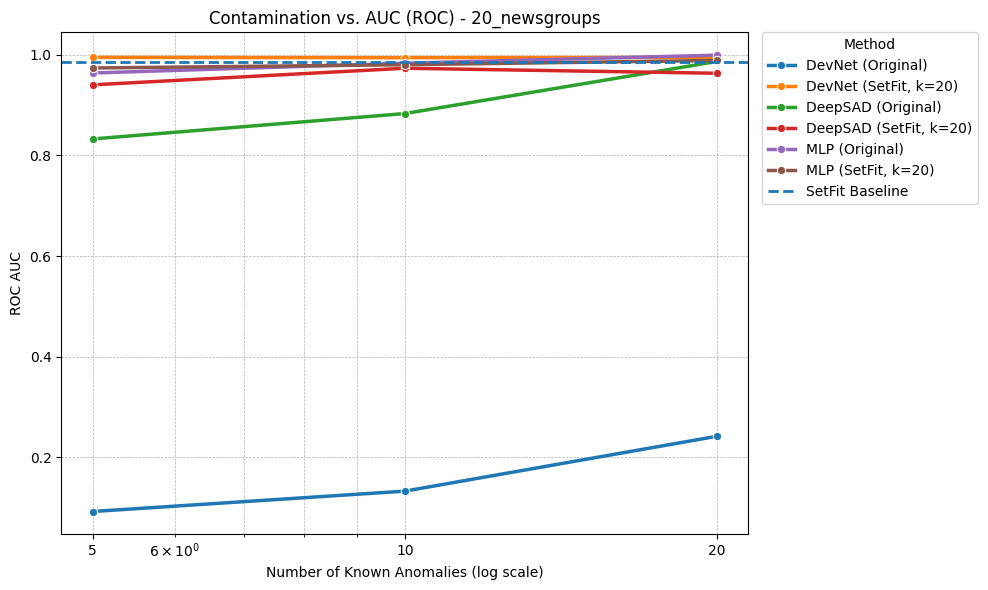

In [ ]:
combined_results = pd.concat(all_results, ignore_index=True)

path_save = f'/content/drive/MyDrive/Projeto ML/2026/Master/Code/plots/curves_auc_per_contamination/N_{K_PER_CLASS}'

if not os.path.exists(path_save):
    os.makedirs(path_save)

plot_semi_supervised_benchmark(
    results_df=combined_results,
    metric="roc_auc",
    baseline_value=metrics["test"]["roc_auc"],
    baseline_label="SetFit Baseline",
    title=f"Contamination vs. AUC (ROC) - {dataset_short}",
    save_path=os.path.join(path_save, f'curves_auc_per_contamination_{dataset_short}.png')
)

In [ ]:
path_csv = f'/content/drive/MyDrive/Projeto ML/2026/Master/Code/results_experiments/auc_comparison_setfit/N_{K_PER_CLASS}'

if not os.path.exists(path_csv):
    os.makedirs(path_csv)

# saving all_results with important information
combined_results['dataset'] = dataset_short
combined_results['encoder'] = encoder_short
combined_results['date'] = datetime.now().strftime("%Y%m%d_%H%M%S")
combined_results.to_csv(os.path.join(path_csv, f'auc_comparison_setfit_{dataset_short}_{encoder_short}.csv'), index=False)